In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import ssl
from torch.utils.data import random_split
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
BATCH_SIZE = 64
IMG_NORM_MEAN = 0.5
IMG_NORM_STD = 0.5
NUM_EPOCHS = 250
TIME_STAMPS = 1000
BETAS = torch.linspace(0.0001,0.02,TIME_STAMPS)
ALPHAS = 1-BETAS
ALPHA_Ts = torch.cumprod(ALPHAS,dim=0)
NUM_CHANNELS = 3 
IMG_HEIGHT = 32
IMG_WIDTH = 32
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using Device = {DEVICE}")

Using Device = mps


In [3]:
class Denoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_embed = nn.Embedding(TIME_STAMPS, 64)
        self.conv1 = nn.Conv2d(3,  64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 3,  kernel_size=3, padding=1)

    def forward(self, noisy_images, time_stamps):
        t_emb = self.time_embed(time_stamps)              # (B, 64)
        t_emb = t_emb.view(-1, BATCH_SIZE, 1, 1)          # (B, 64, 1, 1)
        x = torch.relu(self.conv1(noisy_images))          # (B, 64, 32, 32)
        x = x + t_emb                              
        x = torch.relu(self.conv2(x))
        x = self.conv3(x)
        return x                                        # (B,3,32,32)

    def generate(self):
        with torch.no_grad():
            image = torch.randn(1, NUM_CHANNELS, IMG_HEIGHT, IMG_WIDTH).to(DEVICE)
            for t in range(TIME_STAMPS - 1, -1, -1):
                t_tensor = torch.tensor([t]).to(DEVICE)
                predicted_noise = self.forward(image, t_tensor)
                alpha_t = ALPHAS[t]
                alpha_bar_t = ALPHA_Ts[t]
                beta_t = BETAS[t]
                image = (1 / torch.sqrt(alpha_t)) * (image - (beta_t / torch.sqrt(1 - alpha_bar_t)) * predicted_noise)
                if t > 0:
                    image = image + torch.sqrt(beta_t) * torch.randn_like(image)
            image = image * IMG_NORM_STD + IMG_NORM_MEAN
            image = image.clamp(0, 1)
            image = transforms.ToPILImage()(image.squeeze(0).cpu())
            return image
            

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((IMG_NORM_MEAN,IMG_NORM_MEAN,IMG_NORM_MEAN),
                         (IMG_NORM_STD,IMG_NORM_STD,IMG_NORM_STD))
])
train_val_dataset = datasets.CIFAR10(root="./train_val",download=True,train=True,transform=transform)
test_dataset = datasets.CIFAR10(root="./test",download=True,train=False,transform=transform)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size

train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

In [6]:
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)

In [7]:
denoiser = Denoiser()
denoiser = denoiser.to(DEVICE)
optimizer = torch.optim.Adam(denoiser.parameters(),lr=1e-3)
loss_fn =  nn.MSELoss()

In [ ]:
import os
os.makedirs("model", exist_ok=True)

ALPHA_Ts = ALPHA_Ts.to(DEVICE)
ALPHAS = ALPHAS.to(DEVICE)
BETAS = BETAS.to(DEVICE)

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 30

for epoch in range(NUM_EPOCHS):
    train_loss = 0.0
    val_loss = 0.0
    test_loss = 0.0
    denoiser.train()
    for images,_ in train_loader:
        images = images.to(DEVICE)
        sampled_time_stamps = torch.randint(1,TIME_STAMPS,size=(len(images),)).to(DEVICE)
        random_error_sampled = torch.randn(size=(len(images),NUM_CHANNELS,IMG_HEIGHT,IMG_WIDTH)).to(DEVICE)
        alphats_time_based = ALPHA_Ts[sampled_time_stamps].view(-1,1,1,1)
        new_images = torch.sqrt(alphats_time_based) * images + torch.sqrt(1-alphats_time_based) * random_error_sampled
        predicted_noise = denoiser(new_images,sampled_time_stamps)
        loss = loss_fn(predicted_noise,random_error_sampled)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        denoiser.eval()
        for images,_ in val_loader:
            images = images.to(DEVICE)
            sampled_time_stamps = torch.randint(1,TIME_STAMPS,size=(len(images),)).to(DEVICE)
            random_error_sampled = torch.randn(size=(len(images),NUM_CHANNELS,IMG_HEIGHT,IMG_WIDTH)).to(DEVICE)
            alphats_time_based = ALPHA_Ts[sampled_time_stamps].view(-1,1,1,1)
            new_images = torch.sqrt(alphats_time_based) * images + torch.sqrt(1-alphats_time_based) * random_error_sampled
            predicted_noise = denoiser(new_images,sampled_time_stamps)
            loss = loss_fn(predicted_noise,random_error_sampled)
            val_loss += loss.item()
        for images,_ in test_loader:
            images = images.to(DEVICE)
            sampled_time_stamps = torch.randint(1,TIME_STAMPS,size=(len(images),)).to(DEVICE)
            random_error_sampled = torch.randn(size=(len(images),NUM_CHANNELS,IMG_HEIGHT,IMG_WIDTH)).to(DEVICE)
            alphats_time_based = ALPHA_Ts[sampled_time_stamps].view(-1,1,1,1)
            new_images = torch.sqrt(alphats_time_based) * images + torch.sqrt(1-alphats_time_based) * random_error_sampled
            predicted_noise = denoiser(new_images,sampled_time_stamps)
            loss = loss_fn(predicted_noise,random_error_sampled)
            test_loss += loss.item()

    train_loss = train_loss/len(train_loader)
    val_loss = val_loss/len(val_loader)
    test_loss = test_loss/len(test_loader)
    print(f"Epoch {epoch+1} Train Loss = {train_loss:.6f} Val Loss = {val_loss:.6f} Test Loss = {test_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': denoiser.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'BETAS': BETAS,
            'ALPHAS': ALPHAS,
            'ALPHA_Ts': ALPHA_Ts,
        }, "model/best_model_vanila.pt")
        print(f"  --> Saved best model (val loss: {best_val_loss:.6f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} — no improvement for {PATIENCE} epochs")
            break


Epoch 1 Train Loss = 0.082052 Val Loss = 0.072161 Test Loss = 0.072426
  --> Saved best model (val loss: 0.072161)
Epoch 2 Train Loss = 0.065819 Val Loss = 0.063984 Test Loss = 0.063639
  --> Saved best model (val loss: 0.063984)
Epoch 3 Train Loss = 0.058778 Val Loss = 0.060186 Test Loss = 0.057665
  --> Saved best model (val loss: 0.060186)
Epoch 4 Train Loss = 0.055519 Val Loss = 0.053934 Test Loss = 0.053602
  --> Saved best model (val loss: 0.053934)
Epoch 5 Train Loss = 0.052210 Val Loss = 0.050206 Test Loss = 0.053656
  --> Saved best model (val loss: 0.050206)
Epoch 6 Train Loss = 0.051466 Val Loss = 0.050560 Test Loss = 0.051645
Epoch 7 Train Loss = 0.051557 Val Loss = 0.049976 Test Loss = 0.050347
  --> Saved best model (val loss: 0.049976)
Epoch 8 Train Loss = 0.049417 Val Loss = 0.051075 Test Loss = 0.049982
Epoch 9 Train Loss = 0.049171 Val Loss = 0.050407 Test Loss = 0.049862
Epoch 10 Train Loss = 0.049698 Val Loss = 0.048667 Test Loss = 0.048981
  --> Saved best model (v

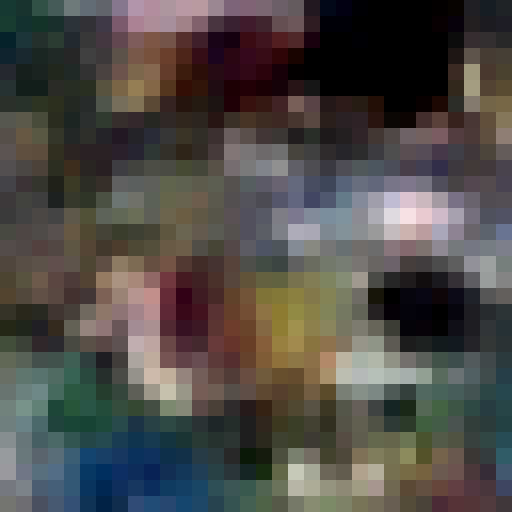

In [15]:
from IPython.display import display
import torchvision.transforms.functional as F

generated = denoiser.generate()
bigger = generated.resize((512,512), resample=0)
display(bigger)